# Report Visualizations for CNN Digit Classifier

This notebook creates the strongest visuals for the report/presentation:

1. **Raw + edge + stroke-density views** to explain the image-processing idea.
2. **Model comparison table/plot** to show what was tested.
3. **Final submission check** for the one Kaggle CSV we care about.
4. **Classical baseline comparison** against HOG + SVM/KNN.

The figures are also saved in `runs/report_visuals/` so they can be inserted into the report or slides.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from torchvision.transforms import functional as TF

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "cnn_classifier_model" / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from iivp_project.config import IMAGE_SIZE
from iivp_project.data import make_edge_view, make_density_view

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
TRAIN_IMG_DIR = DATA_DIR / "train" / "train"
TEST_IMG_DIR = DATA_DIR / "test" / "test"
SUB_DIR = PROJECT_ROOT / "submissions"
OUT_DIR = PROJECT_ROOT / "runs" / "report_visuals"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "font.size": 10,
})

print("output folder:", OUT_DIR)

output folder: /Users/ramezbassous/IIVP-project/runs/report_visuals


## 1. Raw + Edge + Stroke-Density Views

This figure explains the main image-processing idea. Each digit is represented by three channels:

- **Raw grayscale:** the original digit pixels.
- **Sobel edge view:** highlights stroke boundaries and curves.
- **Stroke-density view:** local average intensity, showing where the digit has thicker or more concentrated strokes.

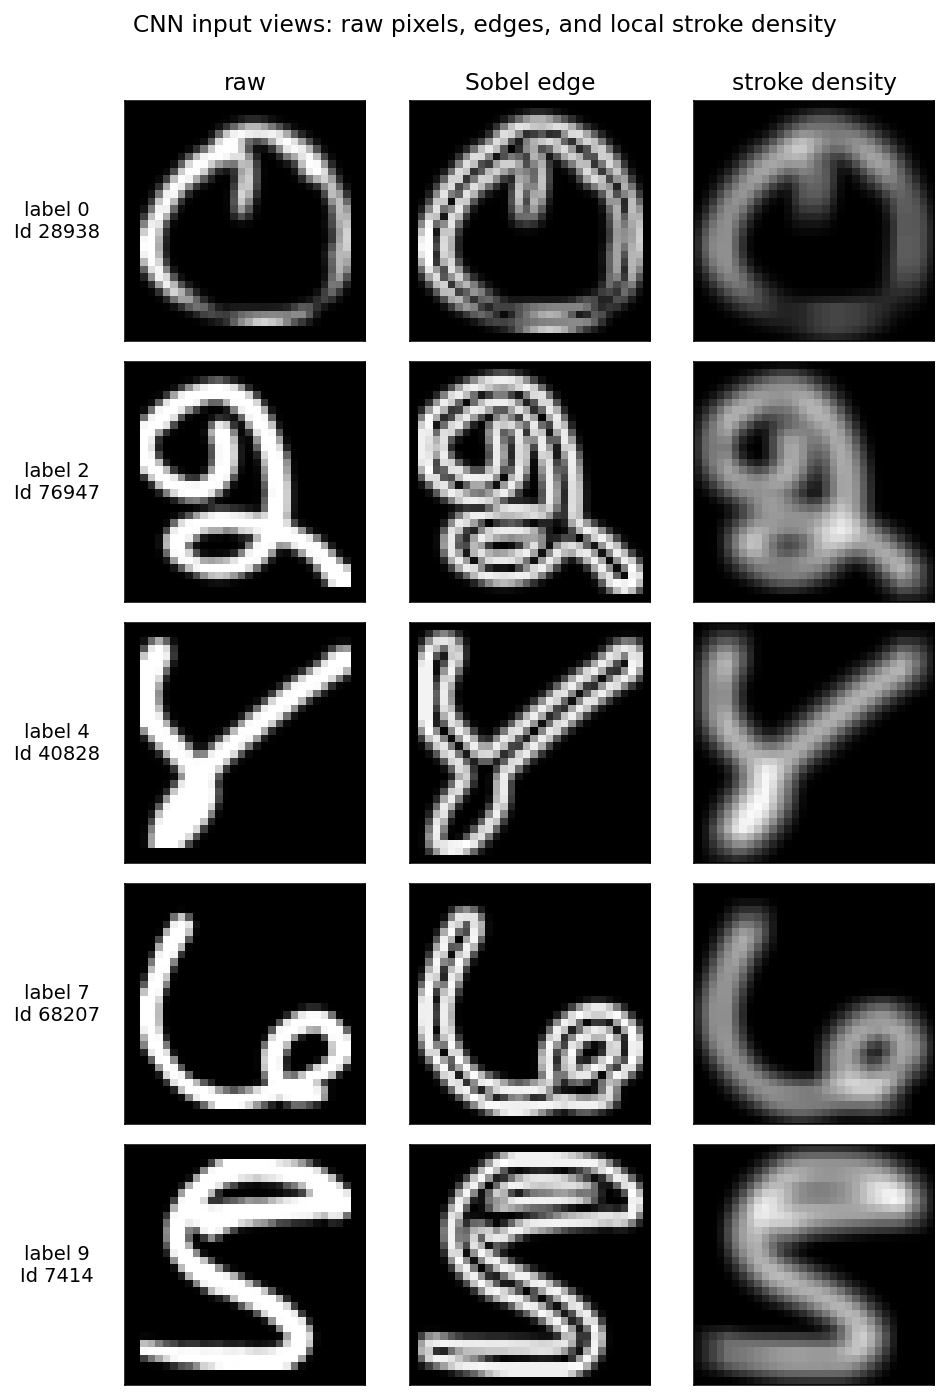

In [2]:
train_df = pd.read_csv(TRAIN_CSV)
examples = []

# Pick a few clear examples from different classes so the figure stays readable.
for label in [0, 2, 4, 7, 9]:
    row = train_df[train_df["Category"] == label].iloc[0]
    image_id = int(row["Id"])
    examples.append((image_id, label, TRAIN_IMG_DIR / str(label) / f"{image_id}.png"))

fig, axes = plt.subplots(len(examples), 3, figsize=(7.2, 2.0 * len(examples)))
for r, (image_id, label, path) in enumerate(examples):
    pil = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    raw = TF.to_tensor(pil)
    edge = make_edge_view(raw)
    density = make_density_view(raw)
    views = [raw.squeeze().numpy(), edge.squeeze().numpy(), density.squeeze().numpy()]
    titles = ["raw", "Sobel edge", "stroke density"]

    for c, (view, title) in enumerate(zip(views, titles)):
        ax = axes[r, c]
        ax.imshow(view, cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 0:
            ax.set_title(title)
        if c == 0:
            ax.set_ylabel(f"label {label}\nId {image_id}", rotation=0, labelpad=35, va="center")

fig.suptitle("CNN input views: raw pixels, edges, and local stroke density", y=0.995)
fig.tight_layout()
fig.savefig(OUT_DIR / "raw_edge_density_grid.png", bbox_inches="tight")
plt.show()

## 2. Model Comparison

This table is useful for the report because it shows that the project was iterative. The scores should be updated if a new Kaggle submission is made.

In [ ]:
model_results = pd.DataFrame([
    {
        "model": "Simple CNN",
        "main change": "raw + edge + density channels",
        "local validation": "1.0000",
        "public Kaggle": "0.9986702",
    },
    {
        "model": "Strong augmentation CNN",
        "main change": "more rotation/translation/scaling/shear",
        "local validation": "1.0000",
        "public Kaggle": "0.9986702",
    },
    {
        "model": "Deeper CNN",
        "main change": "extra convolution block",
        "local validation": "1.0000",
        "public Kaggle": "0.9986702",
    },
    {
        "model": "Final StrokeViewCNN",
        "main change": "100 epochs with raw/edge/density channels",
        "local validation": "1.0000",
        "public Kaggle": "0.9986702",
    },
])

model_results


## 3. Final Submission Check

This section focuses only on the Kaggle file we care about for the final CNN result:

- `submissions/final_submission.csv`

It checks the required Kaggle format, shows the predicted class distribution, and displays a small set of difficult-looking test images with the final model prediction.


In [ ]:
final_submission_path = SUB_DIR / "final_submission.csv"
final_submission = pd.read_csv(final_submission_path).sort_values("Id").reset_index(drop=True)

submission_check = {
    "file": str(final_submission_path),
    "rows": len(final_submission),
    "columns": list(final_submission.columns),
    "duplicate Ids": int(final_submission["Id"].duplicated().sum()),
    "classes predicted": sorted(final_submission["Category"].unique().tolist()),
}
submission_check


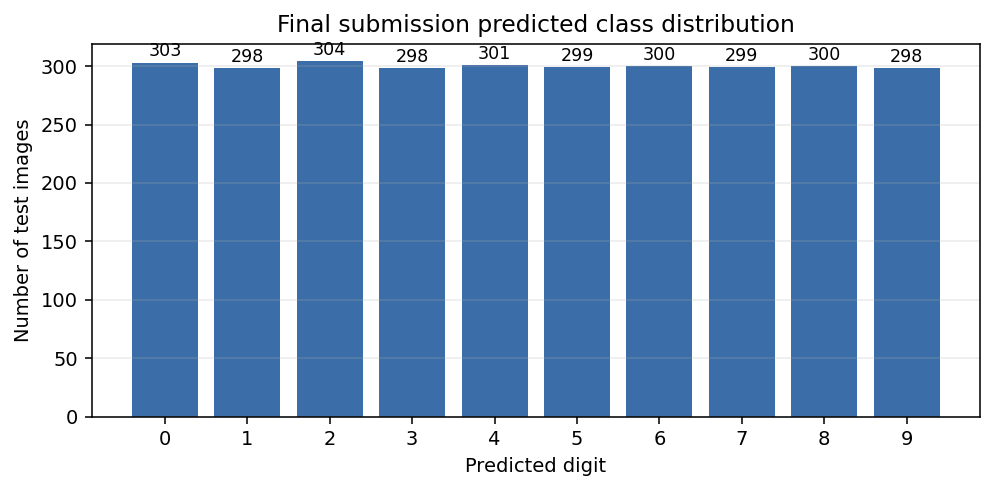

In [5]:
class_counts = final_submission["Category"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.bar(class_counts.index.astype(str), class_counts.values, color="#3b6ea8")
ax.set_xlabel("Predicted digit")
ax.set_ylabel("Number of test images")
ax.set_title("Final submission predicted class distribution")
ax.grid(axis="y", alpha=0.25)
for x, y in zip(class_counts.index.astype(str), class_counts.values):
    ax.text(x, y + 2, str(y), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "final_submission_class_distribution.png", bbox_inches="tight")
plt.show()

In [6]:
# Small manual review set from images that were ambiguous across earlier experiments.
review_ids = [6854, 10297, 39882, 43678, 53131, 71233, 77556, 99457, 99487]
review_df = final_submission[final_submission["Id"].isin(review_ids)].copy()
review_df = review_df.set_index("Id").loc[[i for i in review_ids if i in set(review_df["Id"])]].reset_index()
review_df

,Id,Category
0,6854,0
1,10297,0
2,39882,0
3,43678,2
4,53131,2
5,71233,2
6,77556,4
7,99457,4
8,99487,2


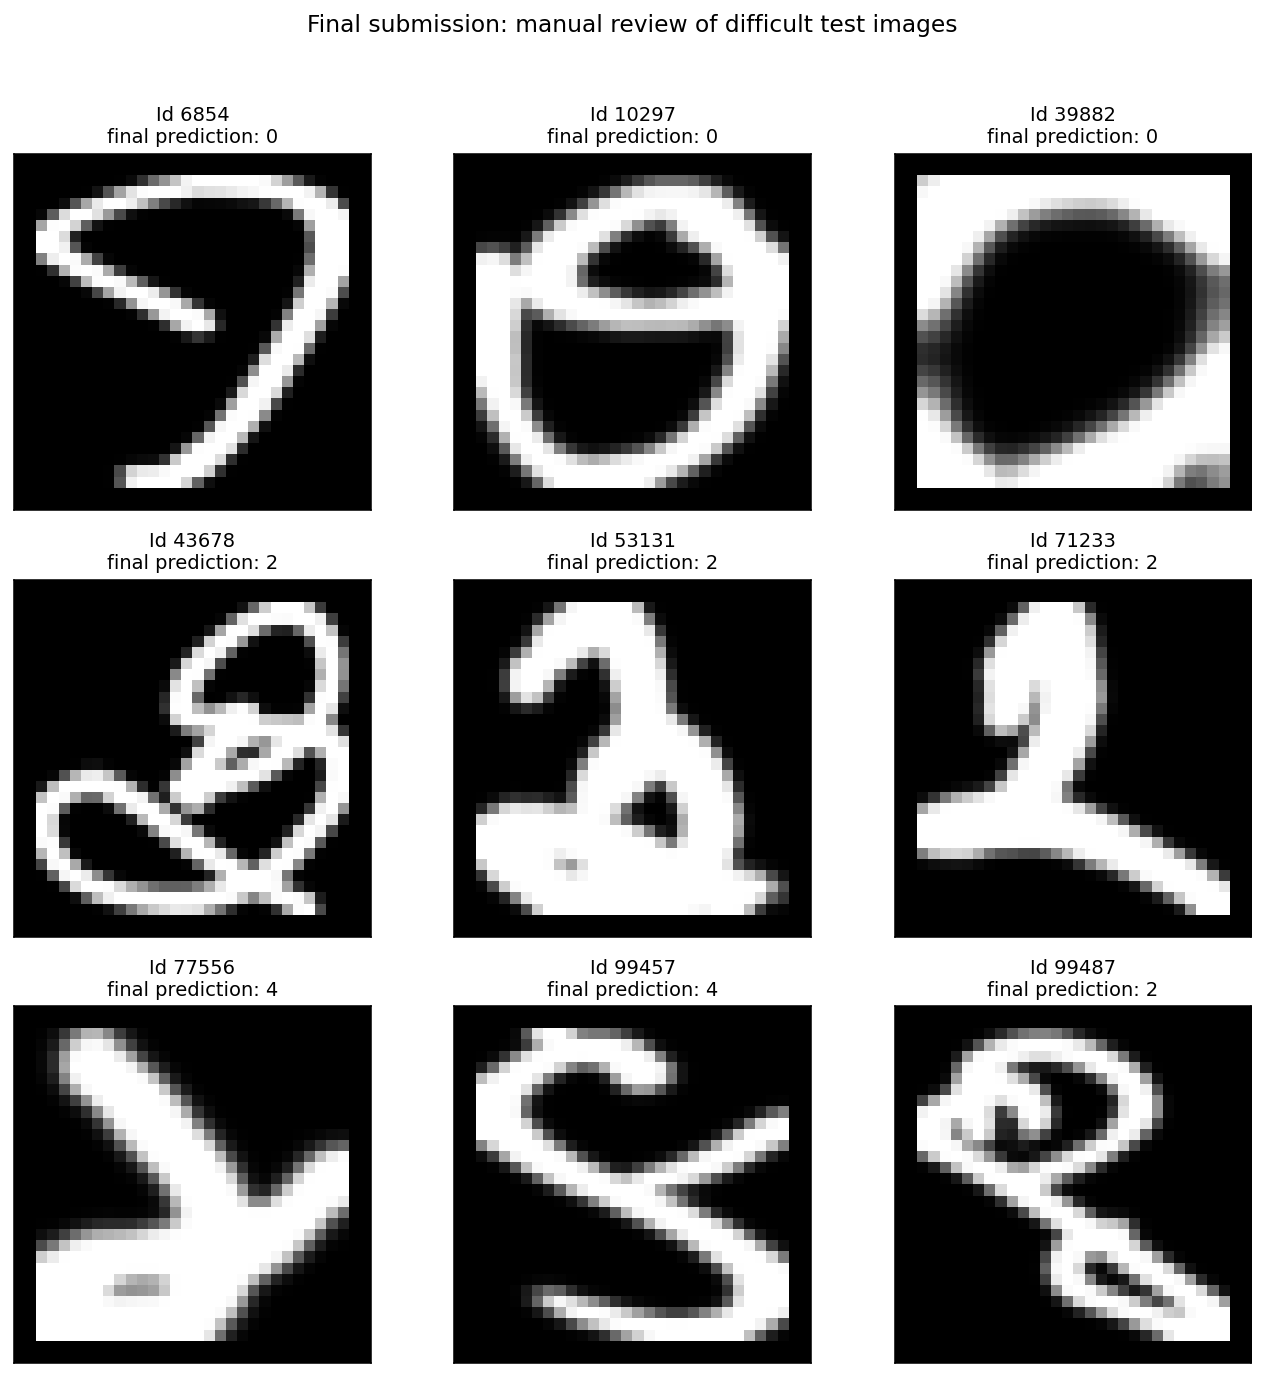

In [7]:
n = len(review_df)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, review_df.iterrows()):
    image_id = int(row["Id"])
    pred = int(row["Category"])
    path = TEST_IMG_DIR / f"{image_id}.png"
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"Id {image_id}\nfinal prediction: {pred}", fontsize=10)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Final submission: manual review of difficult test images", y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "final_submission_review_grid.png", bbox_inches="tight")
plt.show()

## 4. Classical Baselines: HOG + SVM / KNN

This section connects the CNN work to the recognition methods from the course. It compares the CNN approach against classical hand-designed features:

- **HOG features:** gradient/stroke direction descriptors.
- **Linear SVM:** traditional margin-based classifier.
- **KNN:** simple nearest-neighbour baseline.

These are local validation results, not Kaggle public scores, unless a separate submission CSV is created and uploaded.

In [8]:
CLASSICAL_METRICS_PATH = OUT_DIR / "classical_baseline_metrics.csv"
CLASSICAL_CM_PATH = OUT_DIR / "hog_svm_confusion_matrix.png"

if not CLASSICAL_METRICS_PATH.exists():
    raise FileNotFoundError(
        "Missing cached classical metrics. Run the classical baseline script first, "
        "or rerun the notebook section that extracts HOG features."
    )

classical_results = pd.read_csv(CLASSICAL_METRICS_PATH)
print("Classical baselines use a sampled local validation comparison:")
print("300 train images/class and 100 validation images/class")
classical_results

Classical baselines use a sampled local validation comparison:
300 train images/class and 100 validation images/class


,model,feature/method,local validation accuracy
0,HOG + Linear SVM,HOG stroke-direction features,0.971
1,HOG + KNN,HOG nearest-neighbour baseline,0.980


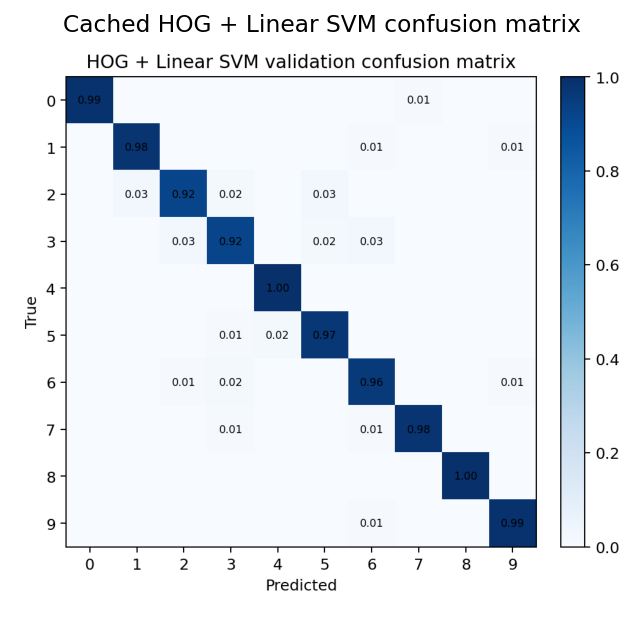

In [9]:
if CLASSICAL_CM_PATH.exists():
    img = plt.imread(CLASSICAL_CM_PATH)
    fig, ax = plt.subplots(figsize=(6.2, 5.2))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title("Cached HOG + Linear SVM confusion matrix")
    plt.show()

In [ ]:
cnn_validation_rows = pd.DataFrame([
    {"model": "Simple CNN", "local validation accuracy": 1.0000},
    {"model": "Strong aug CNN", "local validation accuracy": 1.0000},
    {"model": "Deeper CNN", "local validation accuracy": 1.0000},
    {"model": "Final StrokeViewCNN", "local validation accuracy": 1.0000},
])

val_compare = pd.concat([
    classical_results[["model", "local validation accuracy"]],
    cnn_validation_rows,
], ignore_index=True)
val_compare["model type"] = np.where(val_compare["model"].str.contains("CNN"), "CNN", "classical")
val_compare


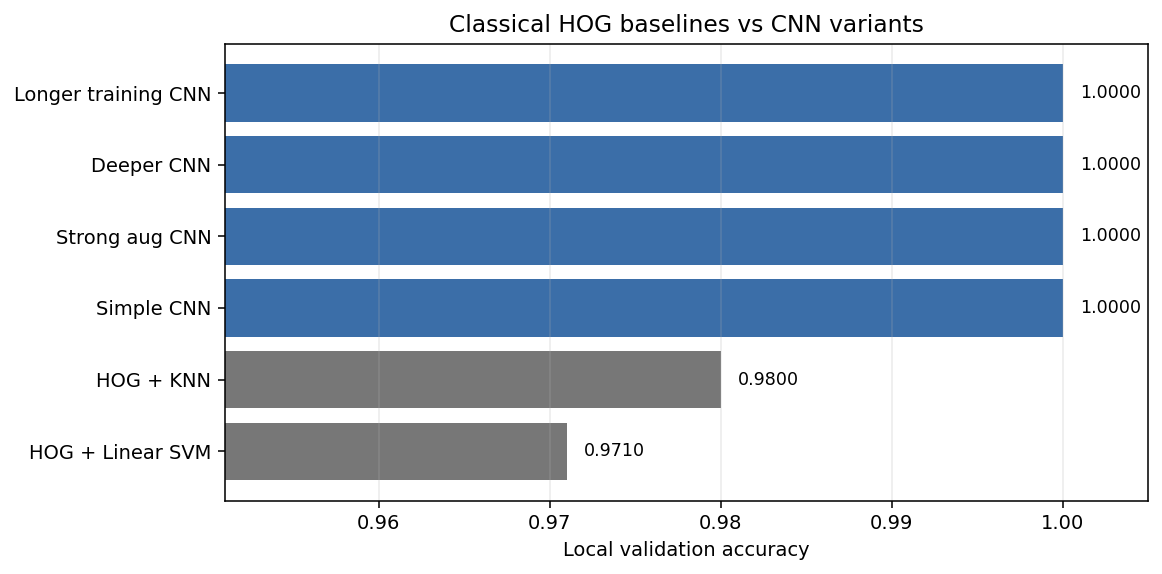

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
colors = val_compare["model type"].map({"classical": "#777777", "CNN": "#3b6ea8"})
ax.barh(val_compare["model"], val_compare["local validation accuracy"], color=colors)
ax.set_xlim(max(0.90, val_compare["local validation accuracy"].min() - 0.02), 1.005)
ax.set_xlabel("Local validation accuracy")
ax.set_title("Classical HOG baselines vs CNN variants")
ax.grid(axis="x", alpha=0.25)
for i, value in enumerate(val_compare["local validation accuracy"]):
    ax.text(value + 0.001, i, f"{value:.4f}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "classical_vs_cnn_validation.png", bbox_inches="tight")
plt.show()

## Saved Figures

The report-ready figures are saved here:

- `runs/report_visuals/raw_edge_density_grid.png`
- `runs/report_visuals/model_comparison_scores.png`
- `runs/report_visuals/final_submission_class_distribution.png`
- `runs/report_visuals/final_submission_review_grid.png`
- `runs/report_visuals/classical_vs_cnn_validation.png`
- `runs/report_visuals/hog_svm_confusion_matrix.png`